# Assignment 2: Marketing Analytics in a Portuguese Bank

Points: 15 pts.

Deliverable: HTML (zip) or PDF file to be submitted through Canvas.

**NOTE: PLEASE DO NOT USE CHATGPT, GEMINI, OR ANY SIMILAR AI CODING TOOL FOR THIS ASSIGNMENT IF, BASED ON YOUR OWN KNOWLDGE, YOU CAN EVALUATE THE CODE THESE TOOLS GENERATE. IF YOU HAVE DIFFICULTY EVALUATING/ UNDERSTANDING THE CODE PRODUCED BY GENAI TOOLS, THEN I HIGHLY RECOMMEND NOT USING THEM YET.** You can use Google search and StackOverflow to troubleshoot your code. The best resources, however, would be our own notebooks (McAfee_PredictiveModel, McAfee_PredictiveModel_v2, AUC_Log_Loss, and UVA Hospital) and materials we discuss during office hours.

**[Please type your first and last name here]**

### Instructions:

The main objective of this assignment is to build, evaluate, and discuss a classification model that predicts the success of telemarketing calls for long-term deposits. we now focus on using matrix-level cost-benefit analysis in training the classifier. We begin with training and evaluating a XGBoost model, and then we use matrix-level cost-benefit analysis to train the classifier in a cost-sensitive way. After that, we compare the costs of the models and decide which one to recommend to the bank.   


**The Assignment:**

The data is related to direct marketing campaigns of a Portuguese retail bank. The marketing campaigns were based on phone calls. The target variable is binary with two possible outcomes: 'yes' and 'no', where 'yes' denotes that the client subscribed to a long-term deposit program and 'no' means the client did not subscribe. Note that `LabelEncoder()` converts 'yes' to 1 and 'no' to 0. The objective is to train and evaluate a classifier that predicts the target variable.

To train the model, we use the input variables (listed below), including bank client data, last contact data, other attributes, and social and economic data. The Python code below builds and evaluates the first model. Please carefully read the code and run the cells until you reach "Assignment Questions". After reading the assignment questions, provide your answers in the cell(s) below each question. After answering the questions and saving this notebook, please click on "File", select "Download as" and select "HTML (.html)" or "PDF" to download the notebook. Then, rename the notebook to "assignment3_firstName_lastName" and submit the notebook through Canvas.


**Input Variables**:

1 - age (numeric)

2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: has credit in default? (categorical: 'no','yes','unknown')

6 - housing: has housing loan? (categorical: 'no','yes','unknown')

7 - loan: has personal loan? (categorical: 'no','yes','unknown')

related with the last contact of the current campaign:

8 - contact: contact communication type (categorical: 'cellular','telephone')

9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')

11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)

14 - previous: number of contacts performed before this campaign and for this client (numeric)

15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

social and economic context attributes

16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)

17 - cons.price.idx: consumer price index - monthly indicator (numeric)

18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)

19 - euribor3m: euribor 3 month rate - daily indicator (numeric)

20 - nr.employed: number of employees - quarterly indicator (numeric)


**Output variable (target variable)**:

21 - y - has the client subscribed to a long-term deposit? (binary: 'yes','no'). Note that `LabelEncoder()` converts 'yes' to 1 and 'no' to 0.


Good Luck!

### 1. Notebook Styling and Package Management

In [1]:
import numpy as np # Library for math operations
import pandas as pd # Library for data handling
import sklearn # The machine learning library we will be using in this entire course
from sklearn import tree # Tree function is used for visualizing decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import * # Importing function that can be used to calculate different metrics 
from sklearn.model_selection import train_test_split # Importing function that can split a dataset into training and testing set
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler # Importing functions for scaling the data
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # Importing GridSearchCV and RandomSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier # Importing the XGBoost Classifier 
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt # Importing the package for plotting
plt.style.use('fivethirtyeight') # Use the styling from FiveThirtyEight Website
import seaborn as sns # Importing another package for plotting

plt.rcParams['figure.figsize'] = [10, 6] ## plot size
plt.rcParams['axes.linewidth'] = 2.0 #set the value globally

### 2. Read the Data File

In [2]:
trainInput = pd.read_csv("bank_train.csv").dropna()
testInput = pd.read_csv("bank_test.csv").dropna()

display(trainInput) # Display the data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,admin.,single,tertiary,no,383,no,yes,cellular,6,feb,119,1,214,1,failure,no
1,53,management,married,tertiary,no,-670,no,yes,cellular,11,jul,86,2,-1,0,unknown,no
2,57,services,married,secondary,no,1,no,no,unknown,7,may,852,1,-1,0,unknown,no
3,50,blue-collar,married,primary,no,1580,yes,no,cellular,14,jul,111,3,-1,0,unknown,no
4,50,services,married,secondary,no,545,no,no,cellular,2,feb,72,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,45,management,married,tertiary,no,126,yes,no,cellular,20,apr,92,1,342,1,failure,no
29996,34,management,married,tertiary,no,1770,yes,no,unknown,6,nov,26,1,101,11,other,no
29997,33,services,single,secondary,no,-27,yes,no,unknown,26,may,165,1,-1,0,unknown,no
29998,33,management,married,tertiary,no,0,yes,no,unknown,23,may,57,5,-1,0,unknown,no


In [3]:
trainInput.info() # This gives us some information about the number of non-null observations and column types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        30000 non-null  int64 
 1   job        30000 non-null  object
 2   marital    30000 non-null  object
 3   education  30000 non-null  object
 4   default    30000 non-null  object
 5   balance    30000 non-null  int64 
 6   housing    30000 non-null  object
 7   loan       30000 non-null  object
 8   contact    30000 non-null  object
 9   day        30000 non-null  int64 
 10  month      30000 non-null  object
 11  duration   30000 non-null  int64 
 12  campaign   30000 non-null  int64 
 13  pdays      30000 non-null  int64 
 14  previous   30000 non-null  int64 
 15  poutcome   30000 non-null  object
 16  y          30000 non-null  object
dtypes: int64(7), object(10)
memory usage: 3.9+ MB


In [4]:
trainInput.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,30000.0,NaN,NaN,NaN,40.910067,10.640624,18.0,33.0,39.0,48.0,95.0
job,30000,12,blue-collar,6410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,30000,3,married,18024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,30000,4,secondary,15450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,30000,2,no,29467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,30000.0,NaN,NaN,NaN,1366.027733,3068.77329,-8019.0,71.0,445.0,1429.0,102127.0
housing,30000,2,yes,16664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,30000,2,no,25223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,30000,3,cellular,19556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,30000.0,NaN,NaN,NaN,15.7971,8.324424,1.0,8.0,16.0,21.0,31.0


In [5]:
trainInput.y.value_counts()

y
no     26490
yes     3510
Name: count, dtype: int64

In [6]:
trainData = trainInput.drop(columns = ['duration','y'])
trainLabels = LabelEncoder().fit_transform(trainInput.y)

testData = testInput.drop(columns = ['duration','y'])
testLabels = LabelEncoder().fit_transform(testInput.y)

In [7]:
trainLabels.sum()

3510

Since some of the predictors in the list above are of type 'object', we encode them into categorical variables using package feature-engine. If this package is not installed, you need to run !pip install feature-engine.

In [8]:
!pip install feature-engine

In [9]:
#trainData.job.value_counts()

trainData['job'].value_counts()

job
blue-collar      6410
management       6371
technician       5034
admin.           3412
services         2742
retired          1510
self-employed    1037
entrepreneur      997
unemployed        860
housemaid         779
student           644
unknown           204
Name: count, dtype: int64

We encode any predictor that is of type object:

In [10]:
from feature_engine.encoding import WoEEncoder

enc = WoEEncoder()

trainData, testData = enc.fit_transform(trainData,trainLabels), enc.transform(testData)

In [11]:
trainData.job.value_counts()

job
-0.527117    6410
 0.176959    6371
-0.052938    5034
 0.016340    3412
-0.269458    2742
 0.826625    1510
-0.070280    1037
-0.391054     997
 0.313652     860
-0.310007     779
 1.089593     644
 0.097464     204
Name: count, dtype: int64

### 3. Create a Model:

In [12]:
%%time
clf = XGBClassifier(random_state = 1)
clf.fit(trainData, trainLabels)

CPU times: user 285 ms, sys: 0 ns, total: 285 ms
Wall time: 151 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 4. Evaluate the Model

In [16]:
predictedProbabilities = clf.predict_proba(testData)
predictedLabels = clf.predict(testData) 
calculateMetricsAndPrint(predictedLabels, predictedProbabilities, testLabels)

print("Log-Loss Score:",log_loss(testLabels, positiveProbabilities))

Accuracy: 89.38
PrecisionNegative: 91.06
PrecisionPositive: 59.98
RecallNegative: 97.55
RecallPositive: 27.71
AUC Score: 78.61

Log-Loss Score: 0.2948583156949438


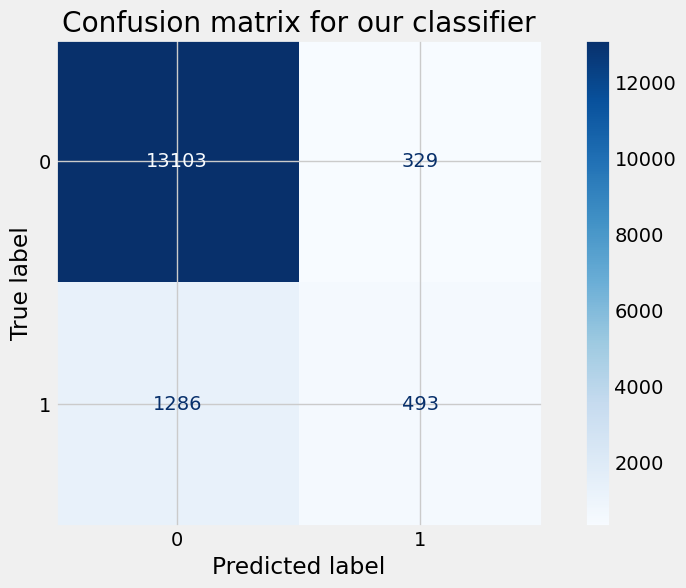

In [15]:
from custom_functions import plot_conf_mat, plot_roc_curve, plot_feature_importance, calculateMetricsAndPrint
plot_conf_mat(clf, # The classifier object
              testData, # The test data set aside for evaluation in train_test_split
              testLabels # Actual labels
             )

AUC Score = 78.606


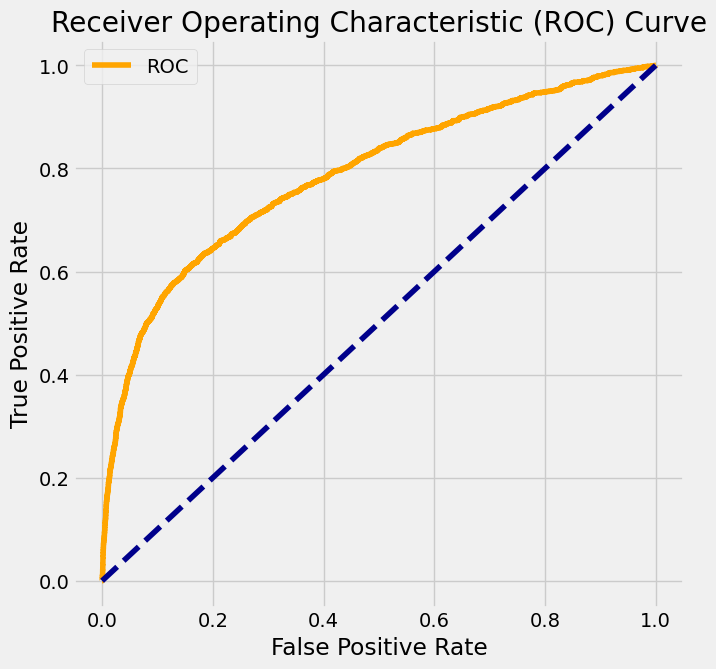

In [17]:
positiveProbabilities = predictedProbabilities[:,1]
plot_roc_curve(testLabels,
               positiveProbabilities,
               pos_label = 1
              )

## Assignment Questions:

#### Q1 [1 point]: Now, use the following classifier to build your model. After training the model, apply it to testData and display the ROC curve and compute log_loss. 

In [18]:
base_estimator = DecisionTreeClassifier(
        max_depth = 6,
        random_state=1
    )
clf1 = AdaBoostClassifier(n_estimators = 101, learning_rate = 0.06546124315277047,  estimator = base_estimator,
                          random_state=1) # This is the classification algo

clf1.fit(trainData, trainLabels)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,101
,learning_rate,0.06546124315277047
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [19]:
predictedProbabilities1 = clf1.predict_proba(testData)
predictedLabels1 = clf1.predict(testData) 
calculateMetricsAndPrint(predictedLabels1, predictedProbabilities1, testLabels)

print("Log-Loss Score:",log_loss(testLabels, predictedProbabilities1))

Accuracy: 89.31
PrecisionNegative: 90.36
PrecisionPositive: 63.08
RecallNegative: 98.39
RecallPositive: 20.74
AUC Score: 79.14

Log-Loss Score: 0.3294905635906768


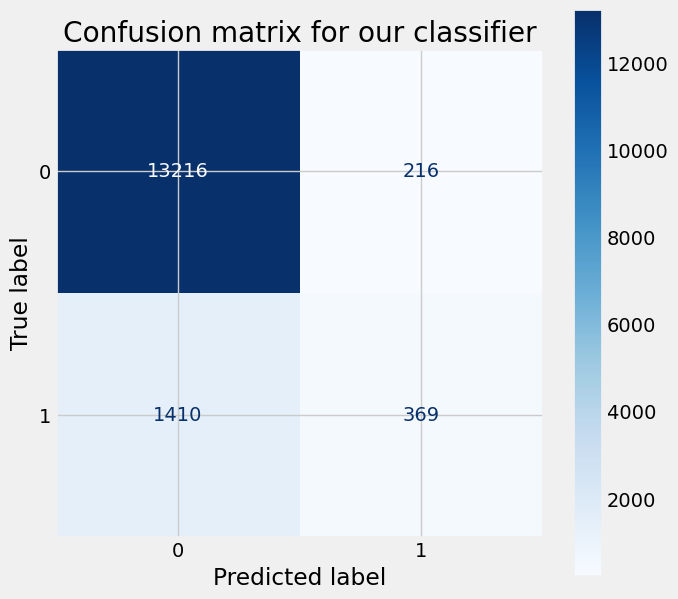

In [20]:
plot_conf_mat(clf1,
              testData,
              testLabels
             )

AUC Score = 79.139


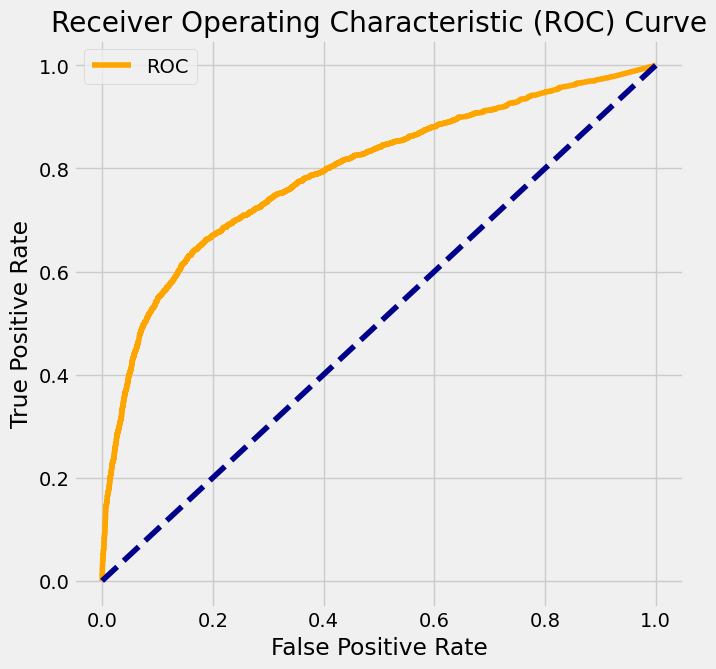

In [23]:
positiveProbabilities1 = predictedProbabilities1[:,1]
plot_roc_curve(testLabels,
               positiveProbabilities1,
               pos_label = 1
              )

#### Q2 [1 point]: Now, use the following classifier to build your model. After training the model, apply it to testData and display the ROC curve and compute log_loss. 

In [24]:
clf2 = XGBClassifier(random_state=1) # This is the classification algo

clf2.fit(trainData, trainLabels)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
predictedProbabilities2 = clf2.predict_proba(testData)
predictedLabels2 = clf2.predict(testData) 
calculateMetricsAndPrint(predictedLabels2, predictedProbabilities2, testLabels)

print("Log-Loss Score:",log_loss(testLabels, positiveProbabilities2))

Accuracy: 89.38
PrecisionNegative: 91.06
PrecisionPositive: 59.98
RecallNegative: 97.55
RecallPositive: 27.71
AUC Score: 78.61

Log-Loss Score: 0.2948583156949438


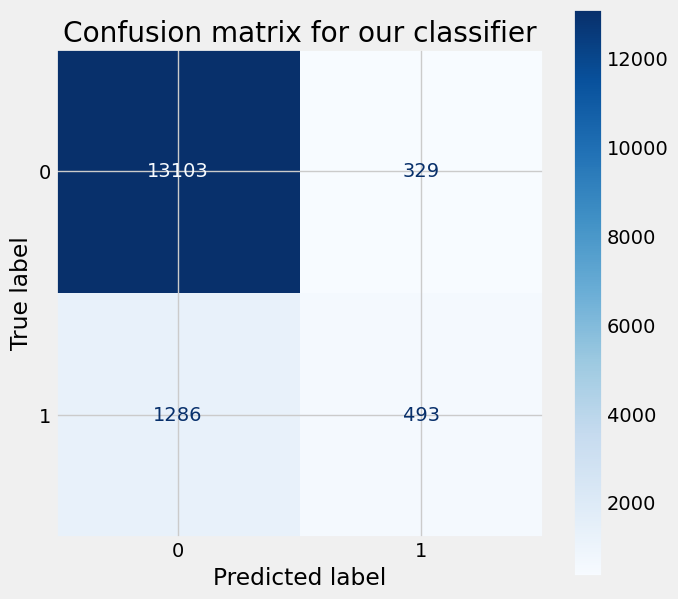

In [26]:
plot_conf_mat(clf2,
              testData,
              testLabels
             )

AUC Score = 78.606


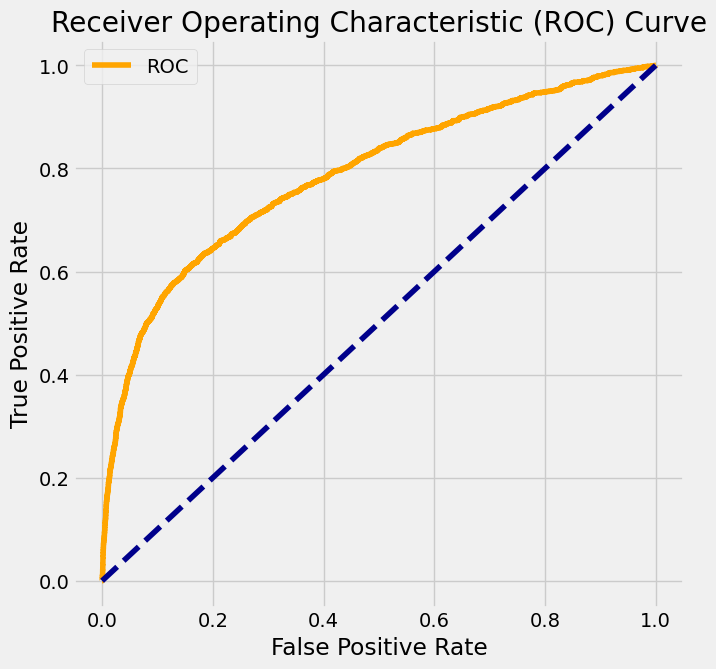

In [27]:
positiveProbabilities2 = predictedProbabilities2[:,1]
plot_roc_curve(testLabels,
               positiveProbabilities2,
               pos_label = 1
              )

#### Q3 [1.5 points]: So far, you created two classifiers: 1- clf1, using AdaBoostClassifier(), and 2- clf2, using XGBClassifier(). For each one of these models, you computed AUC and Log-Loss scores. If you only rely on the AUC score, which one of the two models (clf1 or clf2) would you select as the better model? Now, if you only rely on Log-Loss, which one of the two models (clf1 or clf2) would you select as the better model?

## My Answer

If I was only relying on the AUC score, I would choose the AdaBoostClassifier() (clf1) because it has the highest AUC score of 79.139, which is higher than any other model. The other models are sitting a entire point below at 78.606.

Alternatively, if I were to rely on the Log-Loss, I would choose clf2 over the other classifier since it has a much lower log loss. This means that clf2 is much more confident in its individual predictions than clf1, since the log of its probability of prediction errors is much lower.

Log-Loss References:

clf2 log loss: 0.2948583156949438

clf1 log loss: 0.3294905635906768

#### Q4 [2 points]: Based on the results from Q3, answer the following questions:

##### A) Assume the bank will contact every customer classified as "positive" (predicted to deposit, class label 1). Which model (clf1 or clf2) would you use? Why?

##### B) Assume the bank has a limited budget and can only contact the top 5% of customers with the highest predicted probability of depositing. Which model (clf1 or clf2) would you use? Why?

## My Answer

clf1 True Positives: 369

clf2 True Positives: 493


A) Assuming that the bank will contact everyone that the model predicted to deposit, I would choose clf1. This model has a higher AUC score that represents a enahnced ability for the model to distinguish between the different classes. Even though clf2 predicted a higher number of true positives (493), a higher AUC score is much more important for the longevity and continued profitability of the bank.

B) Assuming the bank has a limited budget and can only contact the top 5% of the customers with the highest predicted probability, I would choose clf2 because it has a lower log-loss. This means that it generally is more confident in its individual predictions and penalizes the predictions that have high probabilities but are incorrect. Thus, the bank is more likely to get a more "reliable" top 5% of customers.

#### Q5 [2 points]: Now, use the following classifier to build a model. Then, identify the top 150 samples/ people in testData that the bank should call (based on the predicted scores from this model). What threshold (t) should you use to identify these 150 samples? 

**Hint:** Once you trained clf, use the following code to copy testData into a new data called temp and then add the predicted prob_ones to temp. Then you can sort your data (ascending or descending) based on column "prob_one" to identify the 150 samples/ applications:

```
temp = testData.copy()
temp["prob_one"] = positiveProbabilities
```

For more information regarding how to sort "temp" based on "prob_one", please refer to https://stackoverflow.com/questions/37787698/how-to-sort-pandas-dataframe-by-one-column as an example. 

In [54]:
clf3 = XGBClassifier(random_state=1) # This is the classification algo

clf3.fit(trainData, trainLabels)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
temp = testData.copy()

In [56]:
predictedProbabilities3 = clf3.predict_proba(testData.copy())
predictedLabels3 = clf3.predict(testData.copy()) 
calculateMetricsAndPrint(predictedLabels3, predictedProbabilities3, testLabels)

print("Log-Loss Score:",log_loss(testLabels, predictedProbabilities3))

Accuracy: 89.38
PrecisionNegative: 91.06
PrecisionPositive: 59.98
RecallNegative: 97.55
RecallPositive: 27.71
AUC Score: 78.61

Log-Loss Score: 0.2948583156949438


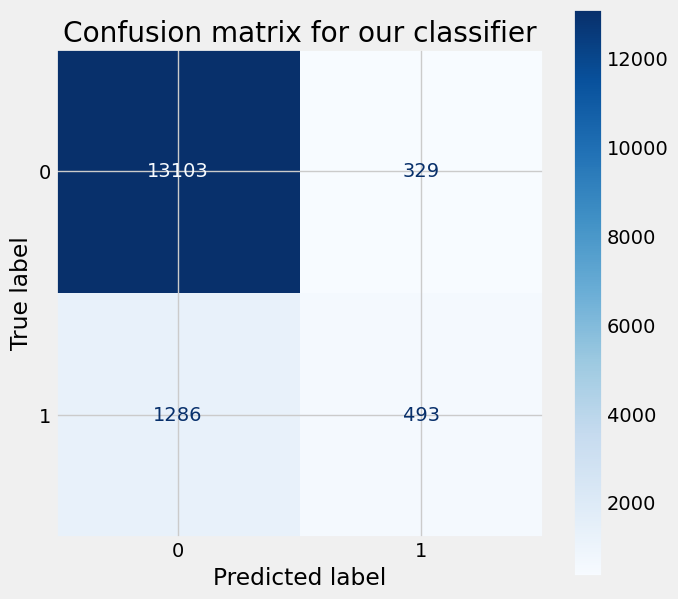

In [57]:
plot_conf_mat(clf3,
              testData.copy(),
              testLabels
             )

AUC Score = 78.606


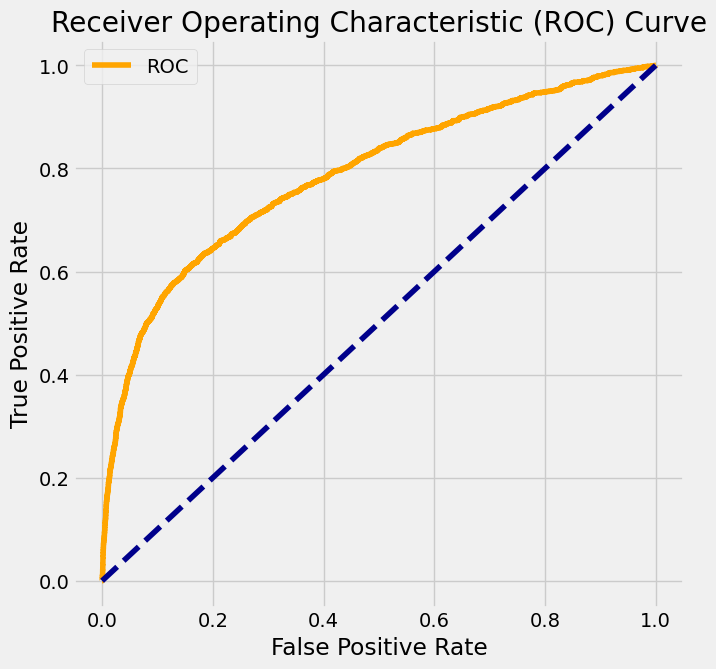

In [58]:
positiveProbabilities3 = predictedProbabilities3[:,1]
plot_roc_curve(testLabels,
               positiveProbabilities3,
               pos_label = 1
              )

In [59]:
#temp.sort_values(by="prob_one", ascending=True)

#display(temp["prob_one"].head(150))

temp["prob_one"] = positiveProbabilities3

top_150 = (temp.sort_values(by="prob_one", ascending=False).head(150))

top_150 = top_150[["prob_one"]]

display(top_150)

,prob_one
14671,0.993133
10954,0.986452
11685,0.984965
14670,0.984196
13004,0.982277
...,...
7857,0.868785
14860,0.868556
10339,0.867569
14418,0.867374


## My Answer

After identifying and displaying the top 150 samples with the highest proability to deposit money, the highest probability is 99.31% and the lowest probability is 86.4%. To decrease the chance that an employee is wasting their time by calling the top 150; I would increase the threshold to 0.864, which is the lowest probability within the baseline top 150 list, so that my model is essentially "more sure" about predicting to Class 1 (deposit). Thus, making the top 150 probabilites more reliable.

**Q6 [2 points]: Let's assume that the average cost of each call is $\$$6, and the average cost of lost opportunity (if we fail to contact a potential depositor who would have made a deposit if contacted) is $\$$100. Given this information, please answer the following questions:**

**a) What is the total cost of a model that predicts everything to be 0?**

**b) What is the total cost of a model that predicts everything to be 1?**

**c) If the bank uses the machine learning model above, how much it would save with respect to scenario b? Please use the confusion matrix above to answer this question.**

**d) Based on your answer to c, does it make sense for the bank to use this model?**


Hint: 

* Cost of each redundant call: $6

* (The lost opportunity) Cost of not calling someone who would have made a deposit: $100

* Total number of samples in the confusion matrix (testData): 15,211

* Total number of phone numbers to call: 1,000,000

## My Answer

In [60]:
#predict everything as 0
predict_everything_0 = ((493 + 1286) * 100) * (1000000/15211)
print(predict_everything_0)

#predict everything as 1
predict_everything_1 = ((13103 + 329) * 6) * (1000000/15211)
print(predict_everything_1)

#model above 
clf_use = ((329 * 6) + (1286 * 100)) * (1000000/15211)
print(clf_use)

11695483.531654723
5298270.988100716
8584182.499506935


In [61]:
cost_savings = predict_everything_1 - clf_use
print(cost_savings)

-3285911.5114062196


A) Total cost of predicting everything to be class 0: $11,695,483.53

B) Total cost of predicting everything to be class 1: $5,298,271

C) If the bank were to use the model above (clf3) it would lose -$3,285,911.5 per 1 million calls.

D) It does not make sense for the bank to use the model above (clf3) because of the imbalanced costs of redundant calls compared to the missed opportunities. It makes more financial sense for the bank to just call everyone, as it only costs 6 dollars per call for redundant calls (calling class 0), and you have a 0 percent chance of an expensive missed opportunity for deposit. The clf3 model allows way too many potential depositors to slip through the cracks and costs the bank $8,584,182 per 1 million calls.

**Q7 [2 points]: Now, retrain the same XGBoost classifier in Q5 but provide the class weights in the model. You should use `scale_pos_weight` inside `XGBClassifier()`. Please set random_state to 1 and do not change anything else.**

**a) Create the confusion matrix for your new classifier.**

**b) What is the total cost of this new (cost-sensitive) model?**

**c) If the bank uses this cost-sensitive model, how much it would save with respect to scenario b in question 1?**

**d) Based on your answer to c, does it make sense for the bank to use this cost-sensitive model?**

## My Answer

In [62]:
cost_xgb = XGBClassifier(scale_pos_weight=100/6, 
                         random_state=1)

cost_xgb.fit(trainData, trainLabels)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


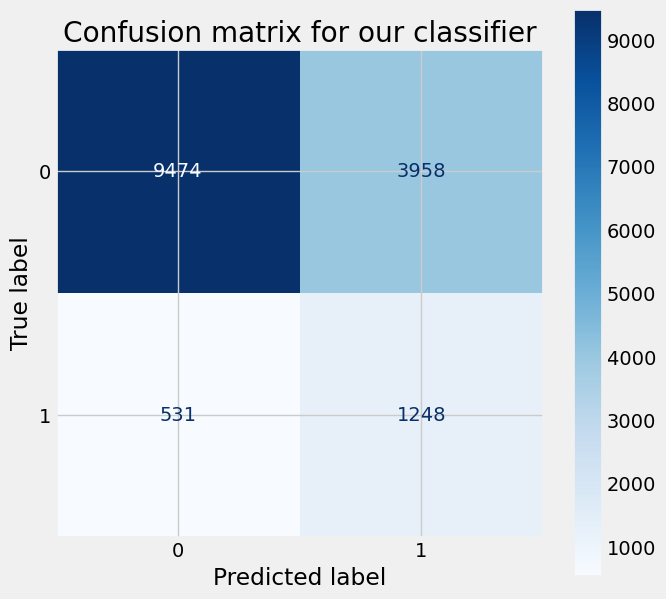

In [63]:
plot_conf_mat(cost_xgb,
              testData,
              testLabels
             )

In [64]:
cost_xgb_cost = ((3958 * 6) + (531 * 100)) * (1000000/15211)
print(cost_xgb_cost)

5052133.324567746


B) The new total cost of this model is $5,052,133.3 per 1 million calls.

In [65]:
amount_saved1 = predict_everything_1 - cost_xgb_cost
print(amount_saved1)

246137.66353296954


C.) If the bank used this new cost sensitive model (cost_xgb), it would save $246,137.7 per 1 million calls compared to scenario B where the bank just calls everyone.

D.) It would make sense for the bank to implement this new cost sensitive model (cost_xgb). Since the new cost sensitive model represents a bank savings of 4.64% compared to Scenario B where the bank just calls everyone.

**Q8 [2 points]: Now, retrain an XGBoost classifier but use HyperOpt to tune the hyperparameters. In addition, provide the class weights in the model. Please still use `scale_pos_weight` inside `XGBClassifier()`. _PLEASE NAME YOUR TUNED XGB `best_xgb`._**

**Note:** Please do not change anything in the cell below. Also, please set max_evals in fmin to 200.

**a) Create the confusion matrix for your new classifier.**

**b) What is the total cost of this new (tuned cost-sensitive) model?**

**c) If the bank uses this tuned cost-sensitive model, how much it would save with respect to scenario b in question 1?**

**d) By comparing the cost savings obtained from the tuned cost-sensitive model (in this question) with the cost savings from the cost-sensitive model in Q2, determine the additional savings due to the tuning.**

In [41]:
!pip install hyperopt

In [42]:
# import packages for hyperparameters tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

space={'max_depth': hp.quniform("max_depth", 3, 18, 1),
        'n_estimators': hp.quniform('n_estimators', 100, 300, 10),
        'eta': hp.uniform ('eta', 0.05,0.9),
        'seed': 0,
        'random_state': 1
    }

from sklearn.metrics import roc_auc_score

def objective(space):
    best_xgb=XGBClassifier(scale_pos_weight = 16.67,
        random_state = space['random_state'],
        eta = space['eta'],
        n_estimators = int(space['n_estimators']), 
        max_depth = int(space['max_depth']))
    
    evaluation = [( trainData, trainLabels), ( testData, testLabels)]
    
    best_xgb.fit(trainData, trainLabels, verbose=False)
    

    pred = best_xgb.predict_proba(testData)[:,1]
    accuracy = roc_auc_score(testLabels, pred)
    print ("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK }

/opt/conda/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [43]:
%%capture --no-display

trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 200,
                        trials = trials)

In [44]:
print("The best hyperparameters are : ","\n")
print(best_hyperparams)

The best hyperparameters are :  

{'eta': 0.12468369472624467, 'max_depth': 4.0, 'n_estimators': 120.0}


In [45]:
best_hyperparams2 = {'eta': 0.12468369472624467,
                   'max_depth': 4,
                   'n_estimators': 120}

best_xgb = XGBClassifier(scale_pos_weight = 16.67, **best_hyperparams2, random_state=1)
best_xgb.fit(trainData, trainLabels)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [46]:
predictedProbabilities = best_xgb.predict_proba(testData)
predictedLabels = best_xgb.predict(testData) 
calculateMetricsAndPrint(predictedLabels, predictedProbabilities, testLabels)

Accuracy: 55.45
PrecisionNegative: 96.03
PrecisionPositive: 18.69
RecallNegative: 51.69
RecallPositive: 83.87
AUC Score: 79.80



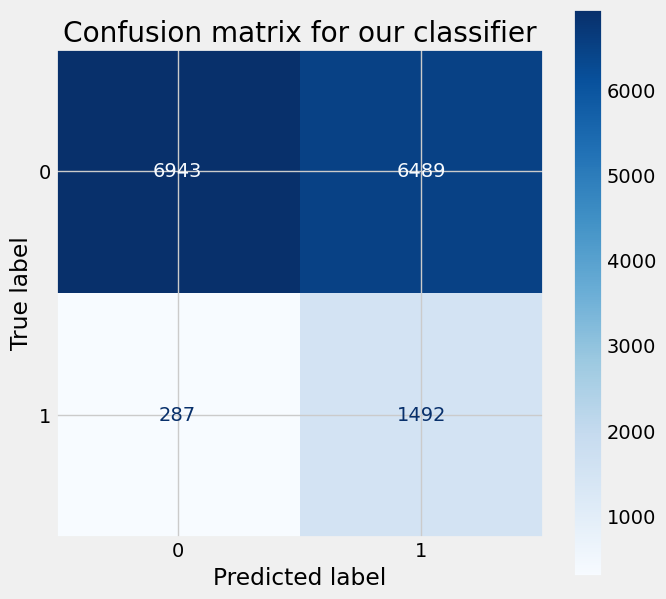

In [47]:
plot_conf_mat(best_xgb,
              testData,
              testLabels
             )

In [48]:
new_cost = ((6489 * 6) + (287 * 100)) * (1000000/15211)
print(new_cost)

4446387.482742751


B) The cost for this new model (best_xgb) is $4,446,387.5.

In [49]:
amount_saved2 = predict_everything_1 - new_cost
print(amount_saved2)

851883.5053579649


C) If the bank implemented this fine tuned cost-sensitive model (best_xgb), the bank would save $851,883.5 per 1 million calls in comparison with scenario B where the bank just calls everyone, even though the precision, recall, and accuracy scores are all much worse. Although, the AUC score did increase to 79.77.

In [50]:
amount_saved3 = cost_xgb_cost - new_cost
print(amount_saved3)

605745.8418249954


D) In comparison with the cost-sensitive model (cost_xgb) from the previous question, the fine-tuned cost-sensitive model (best_xgb) would be save the bank $605,745.8 per 1 million calls.

**Q9 [1.5 points]: Now, let's use SHAP's Waterfall plot to explain the model's predictions.**

**a) In the plot below, we display the plot for the 17th sample in our testData. Which feature has the highest impact in predicting the class label for this sample?**

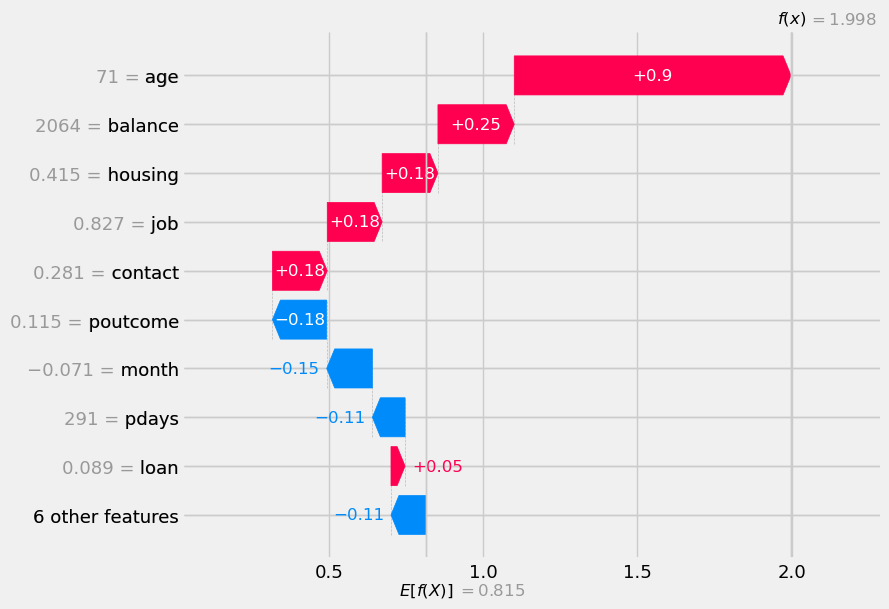

In [51]:
import shap

shap.initjs() # Please do not change this. We use this to create the Shapley plots.
explainer = shap.Explainer(best_xgb)
shap_values = explainer(testData)

# visualize the 16th prediction's explanation
shap.plots.waterfall(shap_values[16])

## My Answer

According to the Shap value plot, the 17th sample's age had the highest imapct on predicting the class label. In this instance, age had a huge influence on the model and pushed it in the direction of choosing class 1.

**b) In the plot below, we display the plot for the 4th sample in our testData. Which feature has the highest impact in predicting the class label for this sample?**

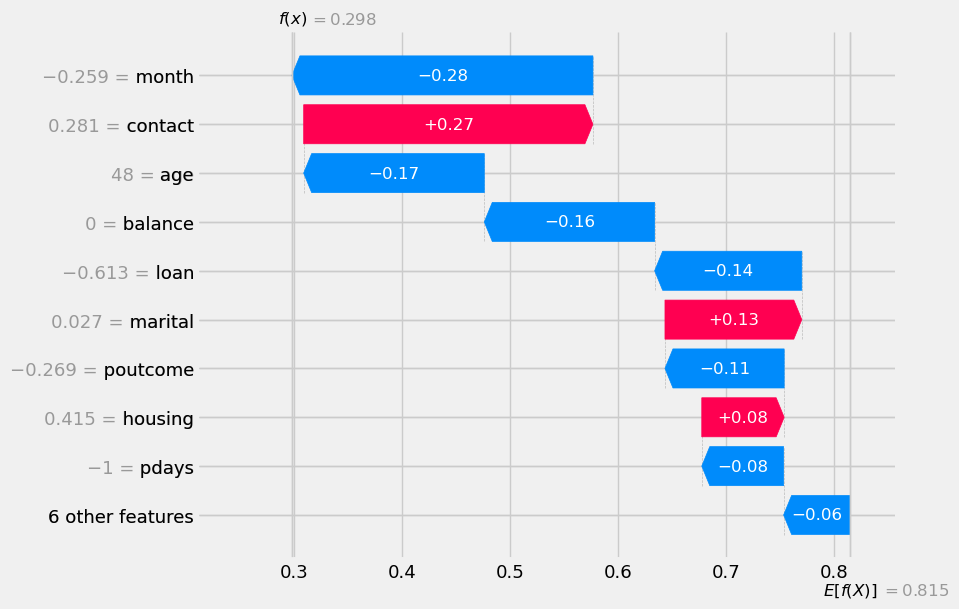

In [53]:
# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[3])

## My Answer

According to the Shap value plot, the 4th sample's last contact month of the year had the highest impact in predicting the class label. In this instance, age had a huge influence on the model and pushed it in the direction of choosing class 0.